Random Forest Accuracy: 83.84%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2311
           1       0.85      0.87      0.86      3264

    accuracy                           0.84      5575
   macro avg       0.83      0.83      0.83      5575
weighted avg       0.84      0.84      0.84      5575



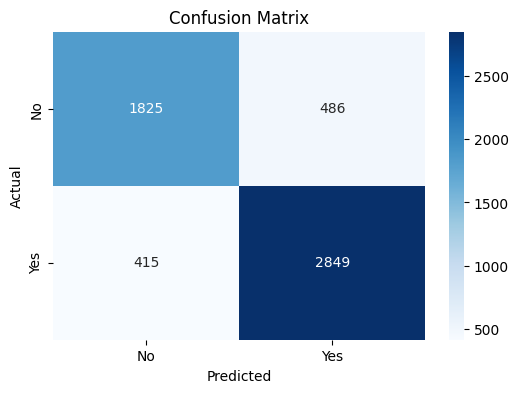

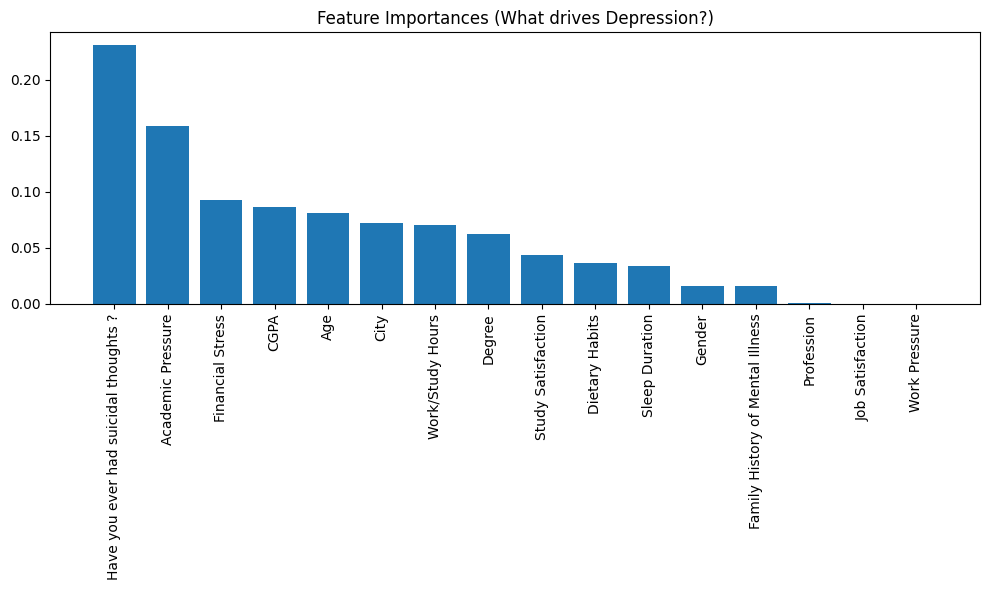

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv('../Data/processed_data_v2.csv')

X = df.drop(columns=['Depression'])
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {acc:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1] 

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (What drives Depression?)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

C:\Users\zeyne\AppData\Local\Temp\ipykernel_19368\3454713448.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(
C:\Users\zeyne\AppData\Local\Temp\ipykernel_19368\3454713448.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(
C:\Users\zeyne\AppData\Local\Temp\ipykernel_19368\3454713448.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(


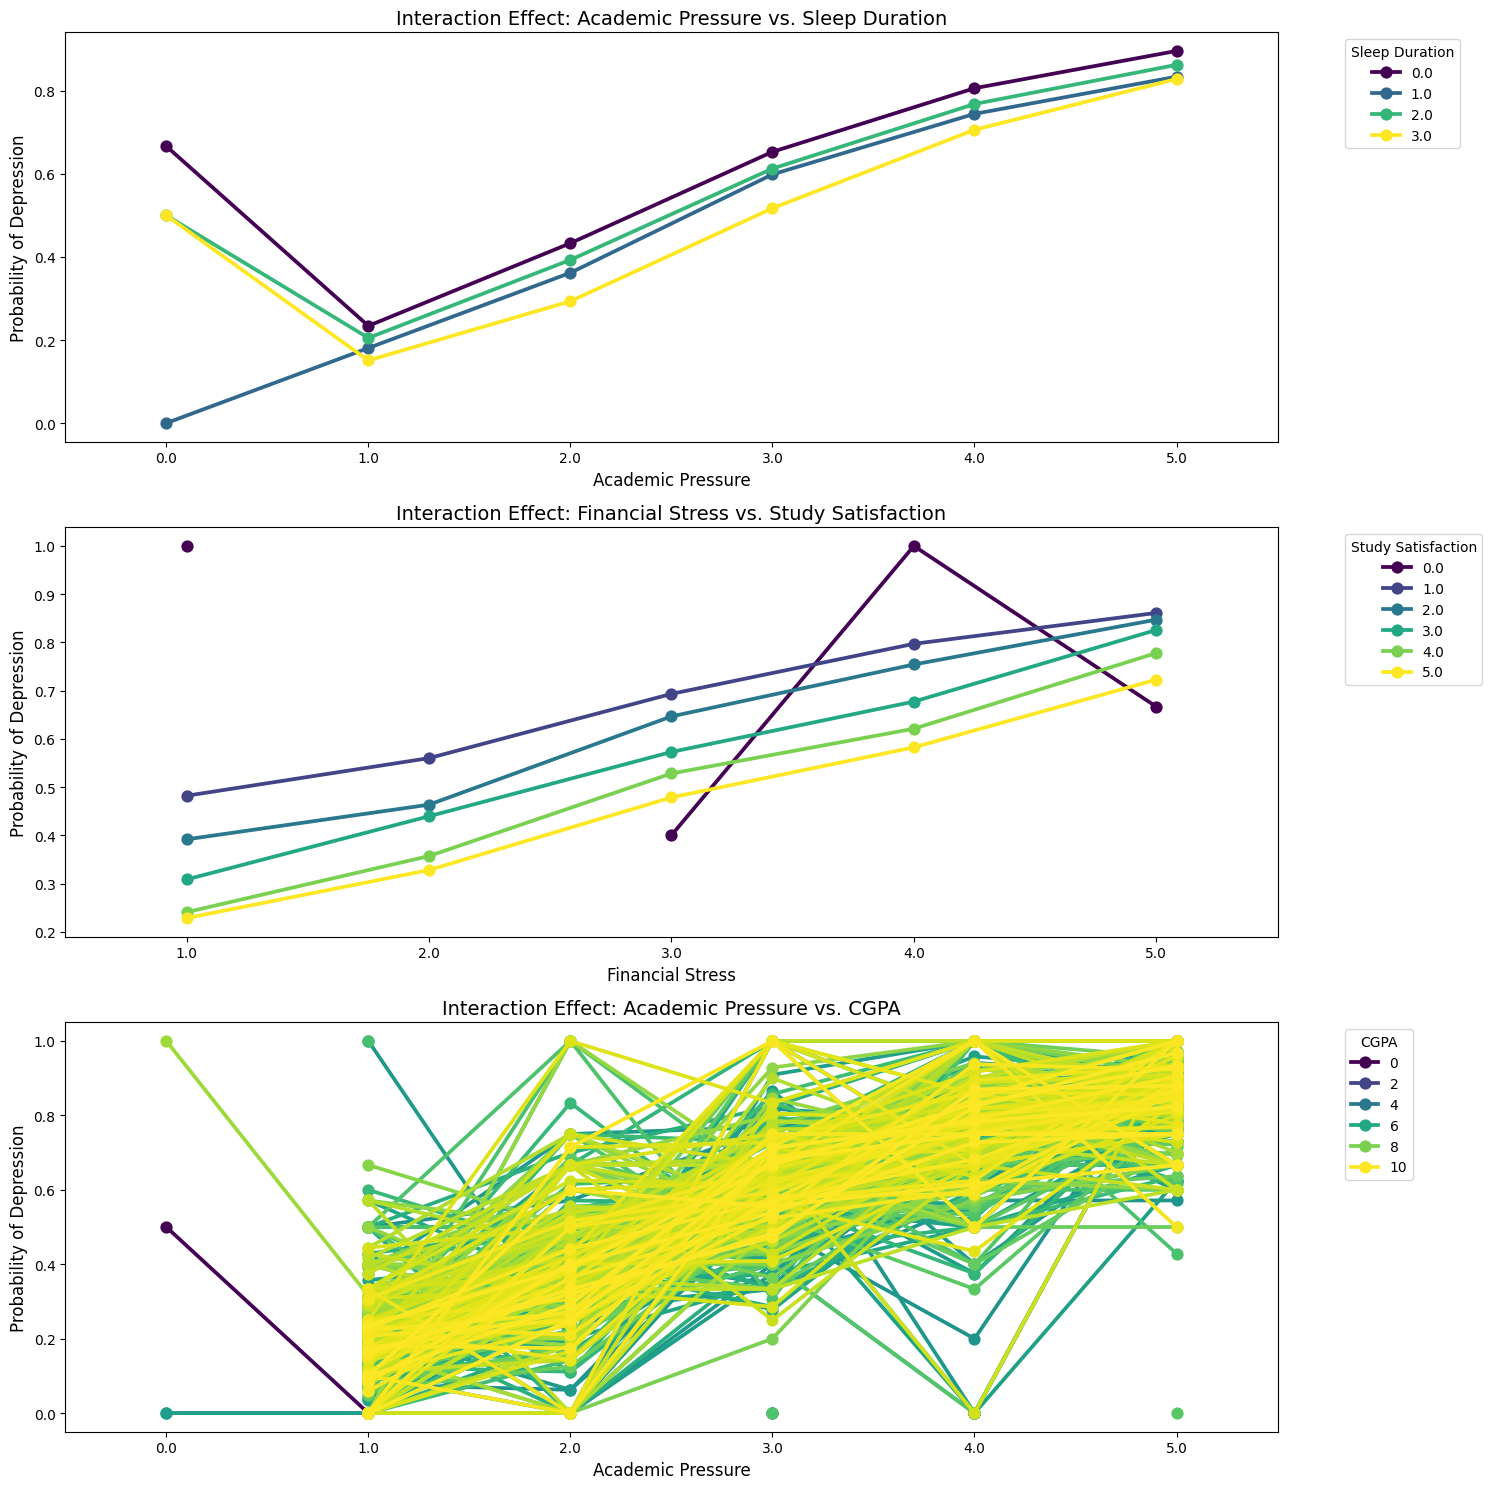

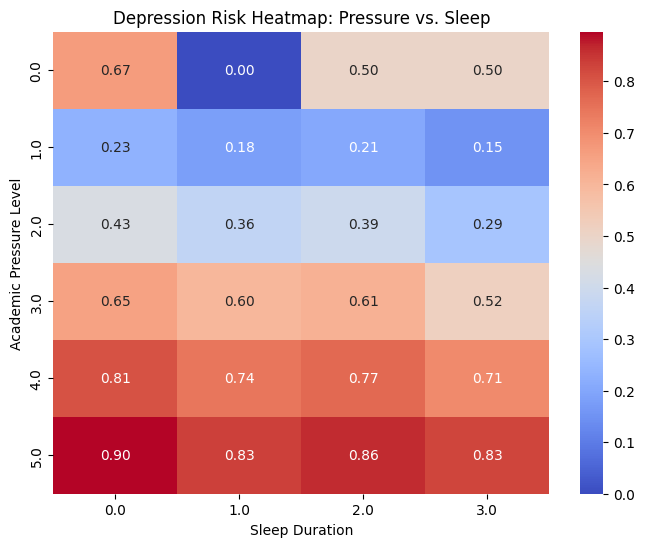

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

interaction_pairs = [
    ('Academic Pressure', 'Sleep Duration'),
    ('Financial Stress', 'Study Satisfaction'),
    ('Academic Pressure', 'CGPA') 
]

plt.figure(figsize=(15, 5 * len(interaction_pairs)))

for i, (x_col, hue_col) in enumerate(interaction_pairs):
    plt.subplot(len(interaction_pairs), 1, i + 1)
    
    sns.pointplot(
        data=df, 
        x=x_col, 
        y='Depression', 
        hue=hue_col, 
        ci=None, 
        palette='viridis' 
    )
    
    plt.title(f'Interaction Effect: {x_col} vs. {hue_col}', fontsize=14)
    plt.ylabel('Probability of Depression', fontsize=12)
    plt.xlabel(x_col, fontsize=12)
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

pivot_table = df.pivot_table(
    index='Academic Pressure', 
    columns='Sleep Duration', 
    values='Depression', 
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Depression Risk Heatmap: Pressure vs. Sleep')
plt.ylabel('Academic Pressure Level')
plt.xlabel('Sleep Duration')
plt.show()

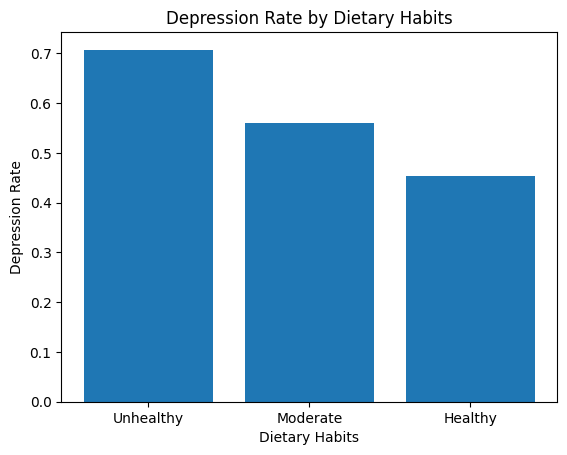

In [4]:
import matplotlib.pyplot as plt

df.groupby('Dietary Habits')['Depression'].mean()
rates = df.groupby('Dietary Habits')['Depression'].mean()

plt.bar(
    ['Unhealthy', 'Moderate', 'Healthy'],
    rates.values
)
plt.ylabel('Depression Rate')
plt.xlabel('Dietary Habits')
plt.title('Depression Rate by Dietary Habits')
plt.show()


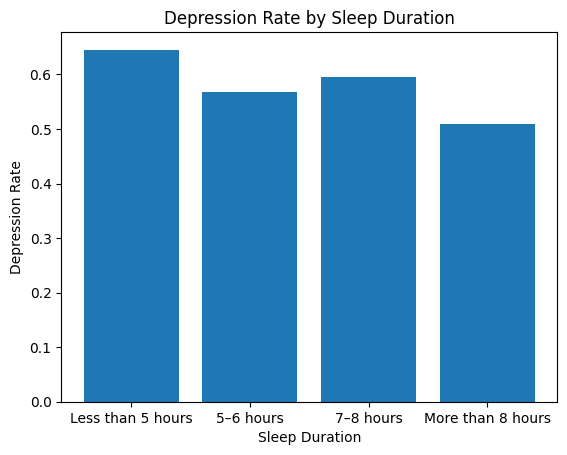

In [3]:
rates = df.groupby('Sleep Duration')['Depression'].mean()

labels = [
    'Less than 5 hours',
    '5–6 hours',
    '7–8 hours',
    'More than 8 hours'
]

plt.bar(labels, rates.values)
plt.ylabel('Depression Rate')
plt.xlabel('Sleep Duration')
plt.title('Depression Rate by Sleep Duration')
plt.show()


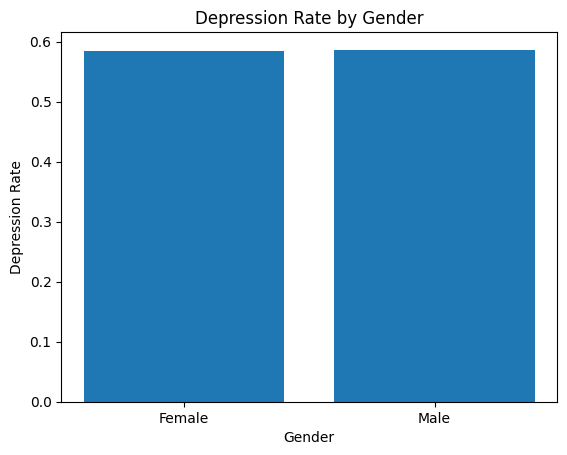

In [4]:
rates = df.groupby('Gender')['Depression'].mean()

labels = ['Female', 'Male']

plt.bar(labels, rates.values)
plt.ylabel('Depression Rate')
plt.xlabel('Gender')
plt.title('Depression Rate by Gender')
plt.show()


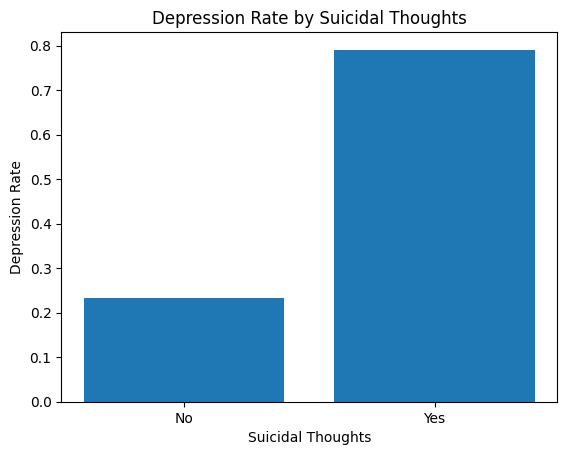

In [5]:
rates = df.groupby('Have you ever had suicidal thoughts ?')['Depression'].mean()

labels = ['No', 'Yes']

plt.bar(labels, rates.values)
plt.ylabel('Depression Rate')
plt.xlabel('Suicidal Thoughts')
plt.title('Depression Rate by Suicidal Thoughts')
plt.show()


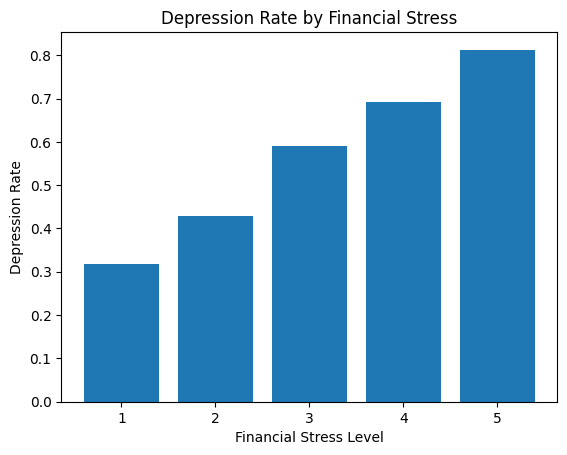

In [6]:
rates = df.groupby('Financial Stress')['Depression'].mean()

plt.bar(rates.index, rates.values)
plt.ylabel('Depression Rate')
plt.xlabel('Financial Stress Level')
plt.title('Depression Rate by Financial Stress')
plt.show()


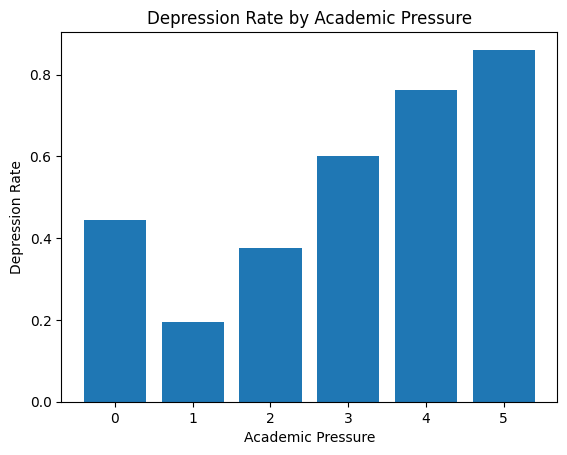

In [7]:
rates = df.groupby('Academic Pressure')['Depression'].mean()

plt.bar(rates.index, rates.values)
plt.ylabel('Depression Rate')
plt.xlabel('Academic Pressure')
plt.title('Depression Rate by Academic Pressure')
plt.show()


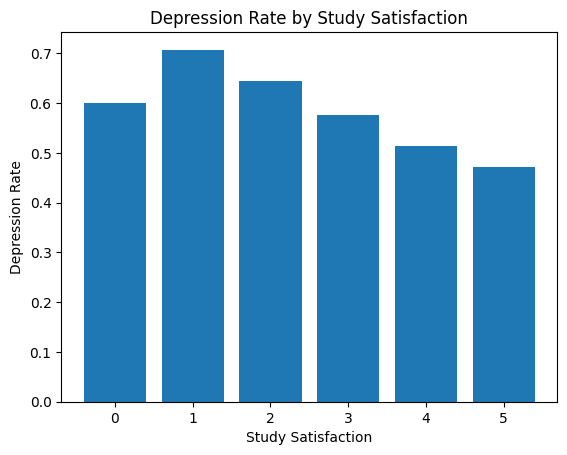

In [8]:
rates = df.groupby('Study Satisfaction')['Depression'].mean()

plt.bar(rates.index, rates.values)
plt.ylabel('Depression Rate')
plt.xlabel('Study Satisfaction')
plt.title('Depression Rate by Study Satisfaction')
plt.show()


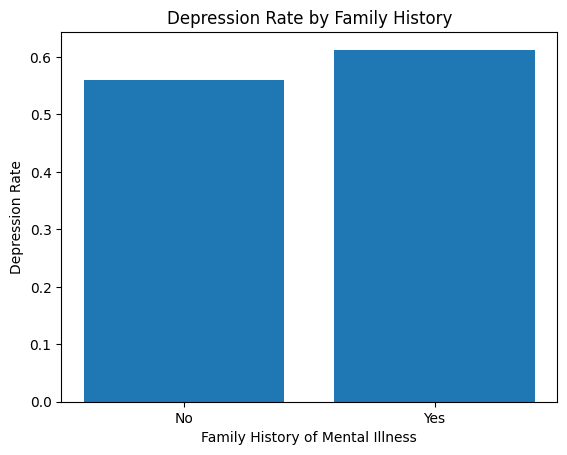

In [9]:
rates = df.groupby('Family History of Mental Illness')['Depression'].mean()

labels = ['No', 'Yes']

plt.bar(labels, rates.values)
plt.ylabel('Depression Rate')
plt.xlabel('Family History of Mental Illness')
plt.title('Depression Rate by Family History')
plt.show()


C:\Users\zeyne\AppData\Local\Temp\ipykernel_31252\1554855594.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby('CGPA_Category')['Depression'].mean()


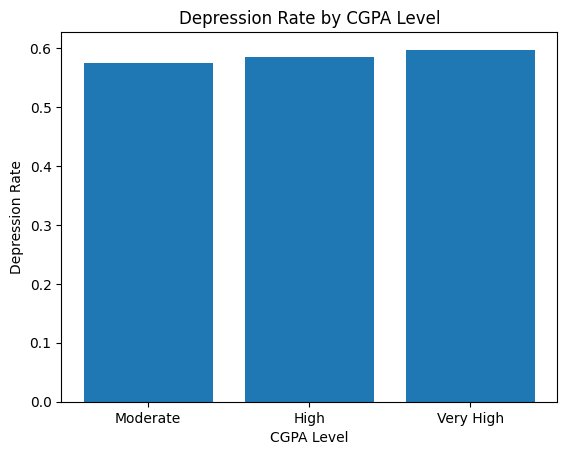

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Create CGPA bins
df['CGPA_Category'] = pd.cut(
    df['CGPA'],
    bins=[0, 5, 7, 8.5, 10],
    labels=['Low', 'Moderate', 'High', 'Very High']
)
rates = df.groupby('CGPA_Category')['Depression'].mean()

plt.bar(rates.index, rates.values)
plt.ylabel('Depression Rate')
plt.xlabel('CGPA Level')
plt.title('Depression Rate by CGPA Level')
plt.show()


ROC–AUC Score: 0.909


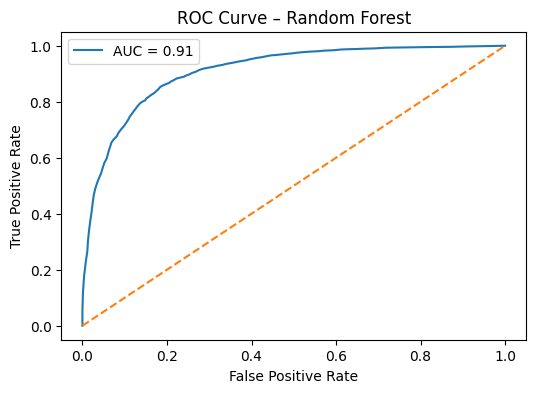

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = rf_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"ROC–AUC Score: {auc:.3f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend()
plt.show()


Random Forest Accuracy: 83.84%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2311
           1       0.85      0.87      0.86      3264

    accuracy                           0.84      5575
   macro avg       0.83      0.83      0.83      5575
weighted avg       0.84      0.84      0.84      5575



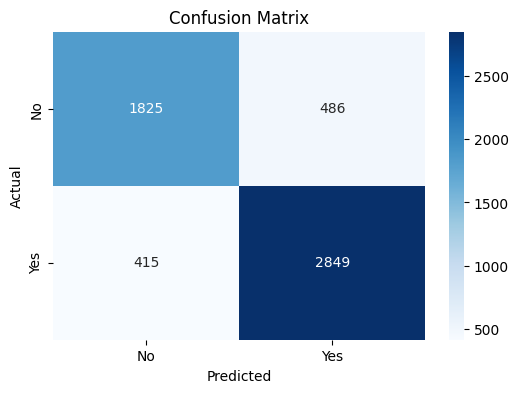

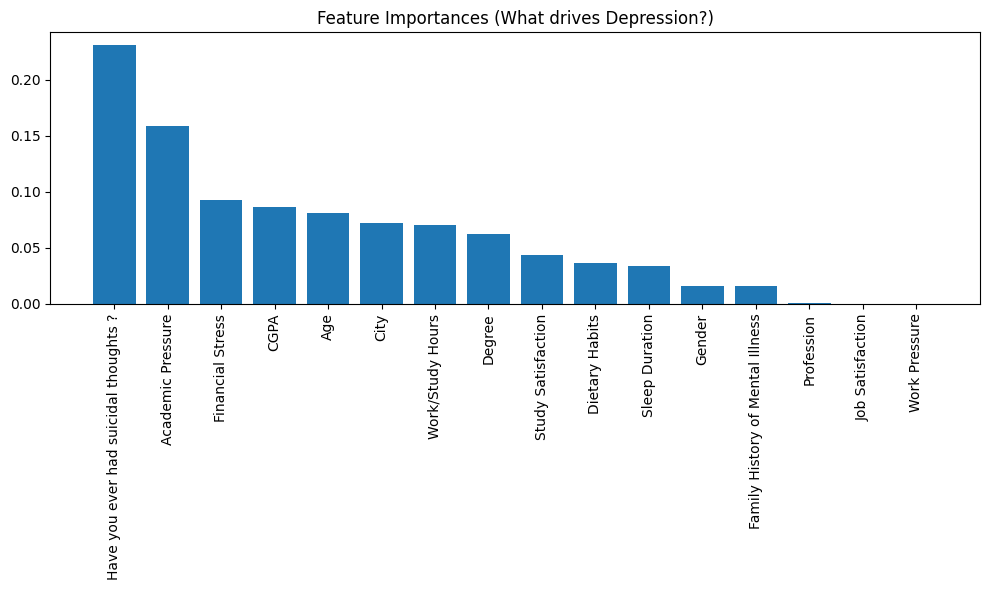

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv('../Data/processed_data_v2.csv')

X = df.drop(columns=['Depression'])
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf_tuned.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {acc:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1] 

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (What drives Depression?)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [4]:
pip install shap

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   -- ------------------------------------ 41.0/548.0 kB 991.0 kB/s eta 0:00:01
   -------- ------------------------------- 112.6/548.0 kB 1.3 MB/s eta 0:00:01
   ------------ --------------------------- 174.1/548.0 kB 1.3 MB/s eta 0:00:01
   ---------------- ----------------------- 225.3/548.0 kB 1.3 MB/s eta 0:00:01
   -------------------- ------------------- 276.5/548.0 kB 1.2 MB/s eta 0:00:01
   ----------------------- ---------------- 317.4/548.0 kB 1.2 MB/s eta 0:00:01
   -------------------------- ------------- 368.6/548.0 kB 1.2 MB/s eta 0:00:01
   ------------------------------ --------- 419.8/548.0 kB 1.2 MB/s eta 0:00:01
   ----------------------------------- ---- 481.3/548.0 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------  542.7/548.0 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 548.0/548.0 kB 1.2 MB/s 


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Random Forest Accuracy: 83.73%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      2311
           1       0.85      0.87      0.86      3264

    accuracy                           0.84      5575
   macro avg       0.83      0.83      0.83      5575
weighted avg       0.84      0.84      0.84      5575



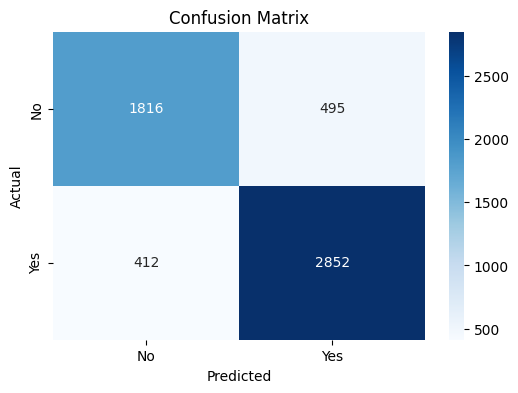

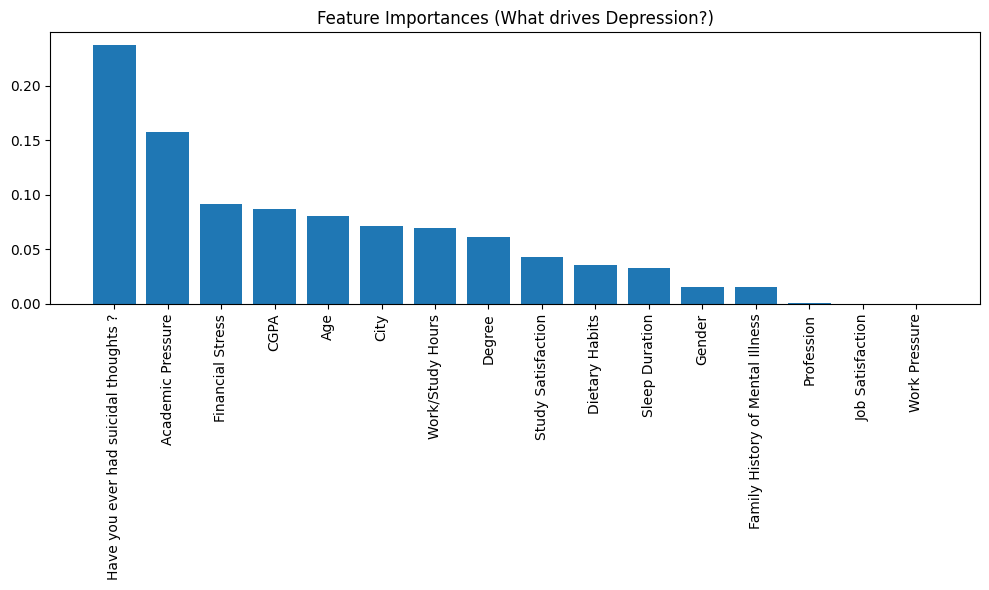

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv('../Data/processed_data_v2.csv')

X = df.drop(columns=['Depression'])
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth= 20)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {acc:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1] 

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (What drives Depression?)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()